# 00 · EDA

Revisar los originales y los resultados de la ingesta. Este notebook solo lee datos.

La primera parte usa data/raw/. La revisión del texto requiere ejecutar 01 y volver a este notebook. Los conteos describen lo descargado.

In [1]:
import hashlib
import json
from pathlib import Path
from urllib.parse import urlsplit

import pandas as pd
from IPython.display import display

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/raw/manifest.json").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Abre este notebook desde la carpeta del proyecto.")
RAW = RAIZ / "data" / "raw"
manifest = json.loads((RAW / "manifest.json").read_text(encoding="utf-8"))
documentos = pd.DataFrame([{k: v for k, v in d.items() if k != "archivos_raw"}
                          for d in manifest])
archivos = pd.DataFrame([dict(a, doc_id=d["doc_id"])
                        for d in manifest for a in d["archivos_raw"]])

## 1. Inventario

In [2]:
archivos["formato"] = archivos["archivo"].map(lambda p: Path(p).suffix.lower())
display(pd.Series({
    "Documentos": len(documentos),
    "Archivos": len(archivos),
    "Tamaño declarado (MiB)": round(archivos["bytes"].sum() / 1024**2, 2),
}, name="Inventario").to_frame())
display(archivos["formato"].value_counts().rename("archivos").to_frame())
display(documentos[["doc_id", "titulo", "fuente", "url"]].head(5))

,Inventario
Documentos,282.00
Archivos,282.00
Tamaño declarado (MiB),116.85


,archivos
formato,
.html,241
.pdf,41


,doc_id,titulo,fuente,url
0,auto_cc_a841_2025,Auto 841 de 2025 - Ley 2381 de 2024,Corte Constitucional - Relatoría,https://www.corteconstitucional.gov.co/relator...
1,co_constitucion_1_1991,Constitución Política de Colombia,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
2,co_decreto_1069_2015,Decreto Único Reglamentario del Sector Justici...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
3,co_decreto_1082_2015,Decreto Único Reglamentario del Sector Adminis...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
4,co_decreto_1083_2015,Decreto Único Reglamentario del Sector de Func...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...


## 2. Cobertura

Un documento puede pertenecer a varias áreas. La suma por área puede superar el total.

In [3]:
display(documentos["areas"].explode().value_counts().rename("documentos").to_frame())
display(documentos["tipo"].value_counts().rename("documentos").to_frame())
display(documentos["anio"].value_counts().sort_index().rename("documentos").to_frame())
dominios = documentos["url"].map(lambda url: urlsplit(url).netloc.lower())
display(dominios.value_counts().rename("documentos por dominio").to_frame())

por_area = documentos.explode("areas", ignore_index=True)
display(pd.crosstab(por_area["areas"], por_area["tipo"]))

,documentos
areas,
constitucional,74
procesal,55
administrativo,44
laboral,43
penal,40
civil,38
familia,30
mercados,25
tributario,20


,documentos
tipo,
ley,171
sentencia,84
decreto,23
decision,2
auto,1
constitucion,1


,documentos
anio,
1873,1
1887,2
1890,1
1932,1
1936,1
1948,1
1950,1
1959,1
1968,1


,documentos por dominio
url,
www.funcionpublica.gov.co,198
www.corteconstitucional.gov.co,47
cortesuprema.gov.co,18
normograma.dian.gov.co,2
www.consejodeestado.gov.co,2
normas.cra.gov.co,2
www.cancilleria.gov.co,2
normograma.superservicios.gov.co,1
cancilleria.gov.co,1


tipo,auto,constitucion,decision,decreto,ley,sentencia
areas,,,,,,
administrativo,0,1,0,4,28,11
civil,0,0,0,2,17,19
comercial_sociedades,0,0,0,3,13,1
constitucional,1,1,0,4,21,47
familia,0,0,0,0,24,6
laboral,1,0,0,5,23,14
mercados,0,0,2,2,16,5
penal,0,0,0,0,31,9
procesal,0,1,0,4,20,30


## 3. Metadatos y procedencia

La fecha de consulta no demuestra vigencia. Los originales marcados con redistribuir_raw en False requieren revisar sus anotaciones antes de publicarlos.


In [4]:
campos = ["doc_id", "titulo", "tipo", "numero", "anio", "organo_emisor",
          "areas", "fuente", "url", "fecha_consulta", "vigencia", "licencia_fuente"]
faltantes = pd.Series({campo: sum(d.get(campo) in (None, "", []) for d in manifest)
                      for campo in campos}, name="faltantes")
display(faltantes.to_frame())
display(documentos.loc[documentos["doc_id"].duplicated(keep=False), ["doc_id", "titulo"]])
display(archivos.loc[archivos["sha256"].duplicated(keep=False), ["doc_id", "archivo", "sha256"]])
display(documentos["vigencia"].value_counts().rename("documentos").to_frame())
revisar_publicacion = documentos.loc[documentos["redistribuir_raw"] != True,
                                    ["doc_id", "titulo", "redistribuir_raw", "edicion_con_anotaciones"]]
display(revisar_publicacion)

,faltantes
doc_id,0
titulo,0
tipo,0
numero,0
anio,0
organo_emisor,0
areas,0
fuente,0
url,0
fecha_consulta,0


,doc_id,titulo


,doc_id,archivo,sha256


,documentos
vigencia,
por_verificar,275
alcance_y_efectos_de_la_providencia,5
requiere_control_temporal_A841_2025_C264_2026,1
consultar_decision_C481_2019_y_efectos_temporales,1


,doc_id,titulo,redistribuir_raw,edicion_con_anotaciones
35,decision_351_1993,Régimen común sobre derecho de autor y derecho...,False,True
36,decision_486_2000,Régimen común de propiedad industrial,False,True
62,ley_1835_2017,Remuneración a autores de obras cinematográficas,False,True
63,ley_1878_2018,Modificaciones al Código de Infancia y Adolesc...,False,True
67,ley_2089_2021,"Prohibición del castigo físico a niñas, niños ...",False,True
89,ley_675_2001,Régimen de propiedad horizontal,False,True
94,ley_84_1873,Código Civil colombiano,False,True
218,ley_1943_2018,Ley de financiamiento de 2018; fuente histórica,False,True
241,ley_28_1932,Régimen patrimonial en el matrimonio,False,True
265,sentencia_ce_suj4005_2020,2020CE-SUJ-4-005 - Deducciones tributarias,False,True


## 4. Integridad

Comparar cada archivo con su tamaño y SHA-256 registrados. Esto verifica la copia, no la corrección jurídica.

In [5]:
def revisar_archivo(archivo):
    ruta = (RAW / archivo["archivo"]).resolve()
    if not ruta.is_relative_to(RAW.resolve()):
        return "ruta fuera de raw"
    if not ruta.is_file():
        return "no encontrado"
    contenido = ruta.read_bytes()
    if not contenido:
        return "vacío"
    if len(contenido) != archivo["bytes"]:
        return "tamaño distinto"
    if hashlib.sha256(contenido).hexdigest() != archivo["sha256"]:
        return "hash distinto"
    return "ok"

integridad = archivos[["doc_id", "archivo"]].copy()
integridad["estado"] = [revisar_archivo(a) for a in archivos.to_dict("records")]
display(integridad["estado"].value_counts().rename("archivos").to_frame())
display(integridad.loc[integridad["estado"] != "ok"])

,archivos
estado,
ok,282


,doc_id,archivo,estado


## Resumen de la ejecución

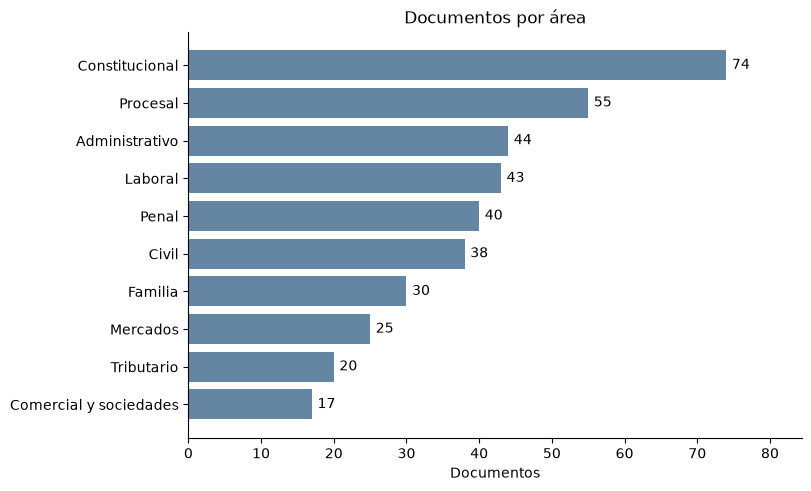

,Total
Documentos,282
Archivos íntegros,282
Campos faltantes,0
Identificadores duplicados,0
Archivos idénticos,0
Vigencia por verificar,275
Publicación por revisar,10


In [6]:
import matplotlib.pyplot as plt

documentos_por_area = documentos["areas"].explode().value_counts().sort_values()
nombres_areas = {
    "constitucional": "Constitucional",
    "administrativo": "Administrativo",
    "penal": "Penal",
    "procesal": "Procesal",
    "comercial_sociedades": "Comercial y sociedades",
    "civil": "Civil",
    "familia": "Familia",
    "tributario": "Tributario",
    "laboral": "Laboral",
    "mercados": "Mercados",
}
fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
barras = ax.barh(documentos_por_area.index.map(nombres_areas), documentos_por_area.values,
                 color="#6486a3")
ax.bar_label(barras, padding=4)
ax.set_title("Documentos por área")
ax.set_xlabel("Documentos")
ax.set_xlim(0, documentos_por_area.max() * 1.14)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

display(pd.Series({
    "Documentos": len(documentos),
    "Archivos íntegros": int((integridad["estado"] == "ok").sum()),
    "Campos faltantes": int(faltantes.sum()),
    "Identificadores duplicados": int(documentos["doc_id"].duplicated().sum()),
    "Archivos idénticos": int(archivos["sha256"].duplicated().sum()),
    "Vigencia por verificar": int((documentos["vigencia"] == "por_verificar").sum()),
    "Publicación por revisar": len(revisar_publicacion),
}, name="Total").to_frame())

## Resultados del inventario

Se revisaron 282 documentos de 10 áreas. Son 241 HTML y 41 PDF.

Los 282 archivos coinciden con sus hashes. No se encontraron archivos idénticos por hash ni faltantes en los campos revisados. Esto no descarta textos similares o versiones de una misma norma.

Hay 275 registros etiquetados como vigencia por verificar y 10 originales con condiciones de publicación por revisar. Los otros 7 registros tampoco certifican vigencia. La revisión jurídica sigue pendiente en los 282 documentos.

## Decisiones

- Conservar los originales y guardar los derivados en data/processed/.
- Mantener las señales de vigencia y las notas de cada fuente.
- Revisar los avisos antes de usar o publicar el corpus.
- Usar los conteos por área para orientar la ampliación. No indican cuánto cubrimos de la evaluación.

## 5. Calidad del texto procesado

Esta parte usa las salidas de 01. Si no existen o el manifiesto cambió, se omite y se indica el motivo.

Se revisan longitudes antes y después de segmentar, repeticiones y avisos. Un hash correcto confirma la copia. No confirma que los artículos estén bien separados.

In [7]:
PROCESADOS = RAIZ / "data/processed/corpus"
necesarios = ["resumen.json", "documentos.jsonl", "unidades.jsonl", "fragmentos.jsonl"]
procesados_disponibles = all((PROCESADOS / nombre).is_file() for nombre in necesarios)

if procesados_disponibles:
    resumen_ingesta = json.loads((PROCESADOS / "resumen.json").read_text(encoding="utf-8"))
    hash_manifest = hashlib.sha256((RAW / "manifest.json").read_bytes()).hexdigest()
    procesados_disponibles = resumen_ingesta.get("sha256_manifest") == hash_manifest
    if not procesados_disponibles:
        print("El manifiesto cambió. Repetir 01 antes de revisar sus salidas.")
else:
    print("Faltan salidas de la ingesta. Ejecutar 01 y volver al EDA.")


def leer_columnas(nombre, campos):
    filas = []
    with (PROCESADOS / nombre).open(encoding="utf-8") as archivo:
        for linea in archivo:
            fila = json.loads(linea)
            filas.append({campo: fila[campo] for campo in campos})
    return pd.DataFrame(filas)


if procesados_disponibles:
    docs = leer_columnas("documentos.jsonl", ["doc_id", "caracteres", "estado_extraccion", "sha256_texto",
                                            "estado_fuente", "apta_para_busqueda", "coincidencias_mojibake"])
    unidades = leer_columnas("unidades.jsonl", ["doc_id", "unidad_id", "tipo_unidad", "articulo", "texto", "estado_segmentacion", "avisos", "apta_para_busqueda"])
    ventanas = leer_columnas("fragmentos.jsonl", ["doc_id", "inicio", "fin"])
    unidades["caracteres"] = unidades["texto"].str.len()
    ventanas["caracteres"] = ventanas["fin"] - ventanas["inicio"]
    display(pd.Series({
        "Versión de ingesta": resumen_ingesta["version_ingesta"],
        "Documentos": len(docs),
        "Unidades": len(unidades),
        "Ventanas": len(ventanas),
        "Artículos": int(unidades["tipo_unidad"].eq("articulo").sum()),
        "Encabezados ambiguos": int(unidades["tipo_unidad"].eq("encabezado_ambiguo").sum()),
        "Controles correctos": resumen_ingesta["comprobaciones_correctas"],
        "Controles totales": resumen_ingesta["comprobaciones_totales"],
    }, name="Ingesta actual").to_frame())
    display(pd.DataFrame({
        "Documentos": docs["caracteres"].describe(percentiles=[.5, .95, .99]),
        "Unidades": unidades["caracteres"].describe(percentiles=[.5, .95, .99]),
        "Ventanas": ventanas["caracteres"].describe(percentiles=[.5, .95, .99]),
    }).round(1))
    display(unidades.groupby("tipo_unidad")["caracteres"].agg(
        cantidad="size", minimo="min", mediana="median",
        p95=lambda x: x.quantile(.95), maximo="max",
    ).round(1))

,Ingesta actual
Versión de ingesta,0.3.0
Documentos,282
Unidades,55449
Ventanas,71402
Artículos,30659
Encabezados ambiguos,5569
Controles correctos,22
Controles totales,22


,Documentos,Unidades,Ventanas
count,282.0,55449.0,71402.0
mean,213818.0,1087.4,887.6
std,381977.1,1514.1,626.8
min,2848.0,3.0,2.0
50%,80740.0,582.0,723.0
95%,948084.4,4572.0,1799.0
99%,1709417.2,5993.0,1800.0
max,3296942.0,39046.0,1800.0


,cantidad,minimo,mediana,p95,maximo
tipo_unidad,,,,,
articulo,30659,9,594.0,2953.1,34011
bloque_jurisprudencia,2479,16,5948.0,5996.0,6000
encabezado_ambiguo,5569,8,668.0,3523.2,39046
indice,2,1990,2661.0,3264.9,3332
parrafo,11416,3,662.0,3496.2,5993
preambulo,238,52,315.5,3479.6,5604
seccion,5086,8,49.0,490.8,16524


### Longitudes y valores atípicos

Comparar las unidades dentro de su tipo. El criterio de 1.5 veces el rango intercuartílico señala casos para revisar. No demuestra que estén mal y no se usa para borrarlos.

Las ventanas tienen un límite de 1800 caracteres. El pico junto al límite es esperado. Para detectar cortes incorrectos también hay que mirar las unidades completas y leer ejemplos.

,unidades,atipicas
tipo_unidad,,
articulo,30659,2576
bloque_jurisprudencia,2479,155
encabezado_ambiguo,5569,418
indice,2,0
parrafo,11416,1021
preambulo,238,26
seccion,5086,514


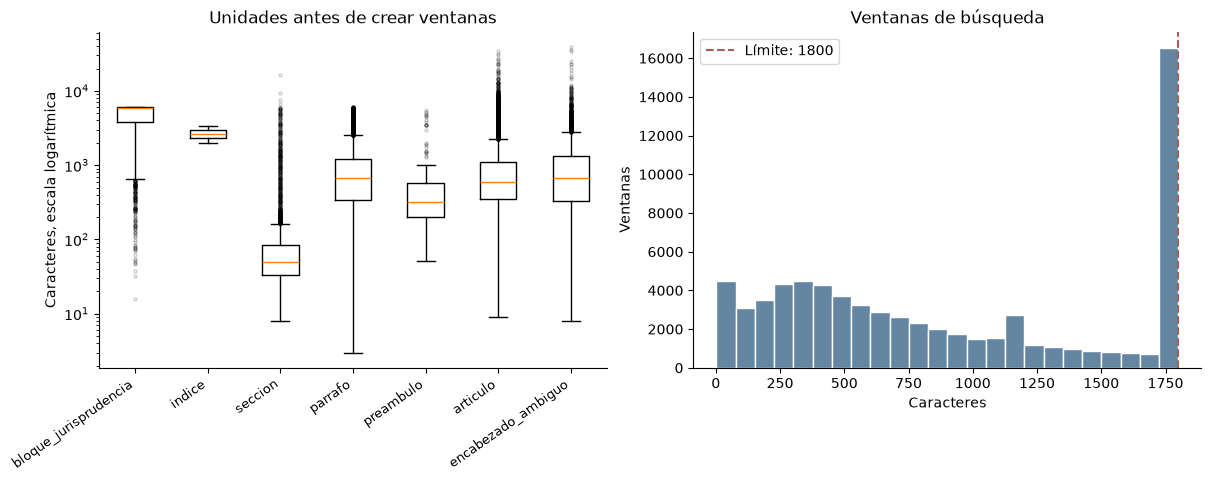

,doc_id,unidad_id,tipo_unidad,articulo,caracteres
17768,decreto_1625_2016,decreto_1625_2016__u00920,encabezado_ambiguo,None,39046
19216,decreto_1625_2016,decreto_1625_2016__u02368,encabezado_ambiguo,None,36017
25515,decreto_663_1993,decreto_663_1993__u00385,encabezado_ambiguo,None,34578
15816,decreto_1081_2015,decreto_1081_2015__u00704,articulo,2.3.1.5.2.1.1,34011
25481,decreto_663_1993,decreto_663_1993__u00351,articulo,300,31798
18299,decreto_1625_2016,decreto_1625_2016__u01451,articulo,16.1.2.11,30032
12810,decreto_1074_2015,decreto_1074_2015__u00207,articulo,2.2.1.7.2.1,27214
19368,decreto_1833_2016,decreto_1833_2016__u00152,articulo,2.2.4.4.2,26533
6742,co_ley_1150_2007,co_ley_1150_2007__u00004,articulo,2,25128
4449,co_decreto_1082_2015,co_decreto_1082_2015__u00235,encabezado_ambiguo,None,24947


,doc_id,unidad_id,tipo_unidad,articulo,caracteres,inicio_texto
51790,sentencia_cc_su214_2016,sentencia_cc_su214_2016__u00092,parrafo,None,3,2.\n
51698,sentencia_cc_su075_2018,sentencia_cc_su075_2018__u00354,parrafo,None,4,281.
864,co_constitucion_1_1991,co_constitucion_1_1991__u00010,encabezado_ambiguo,None,8,Art. 3;
889,co_constitucion_1_1991,co_constitucion_1_1991__u00035,encabezado_ambiguo,None,8,Art. 5;
971,co_constitucion_1_1991,co_constitucion_1_1991__u00117,encabezado_ambiguo,None,8,Art. 8;
1048,co_constitucion_1_1991,co_constitucion_1_1991__u00194,encabezado_ambiguo,None,8,Art. 2;
1099,co_constitucion_1_1991,co_constitucion_1_1991__u00245,encabezado_ambiguo,None,8,Art. 5;
1161,co_constitucion_1_1991,co_constitucion_1_1991__u00307,encabezado_ambiguo,None,8,Art. 9;
1219,co_constitucion_1_1991,co_constitucion_1_1991__u00365,encabezado_ambiguo,None,8,Art. 3;
1249,co_constitucion_1_1991,co_constitucion_1_1991__u00395,encabezado_ambiguo,None,8,Art. 5;


In [8]:
if procesados_disponibles:
    q1 = unidades.groupby("tipo_unidad")["caracteres"].transform(lambda x: x.quantile(.25))
    q3 = unidades.groupby("tipo_unidad")["caracteres"].transform(lambda x: x.quantile(.75))
    iqr = q3 - q1
    unidades["atipica_iqr"] = (unidades["caracteres"] < q1 - 1.5 * iqr) | (unidades["caracteres"] > q3 + 1.5 * iqr)
    display(unidades.groupby("tipo_unidad")["atipica_iqr"].agg(unidades="size", atipicas="sum"))

    tipos = unidades["tipo_unidad"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), layout="constrained")
    axes[0].boxplot([unidades.loc[unidades["tipo_unidad"] == tipo, "caracteres"] for tipo in tipos],
                    flierprops={"markersize": 2, "alpha": .2})
    axes[0].set_xticks(range(1, len(tipos) + 1), tipos, rotation=35, ha="right", fontsize=9)
    axes[0].set_yscale("log")
    axes[0].set_title("Unidades antes de crear ventanas")
    axes[0].set_ylabel("Caracteres, escala logarítmica")
    axes[1].hist(ventanas["caracteres"], bins=24, color="#6486a3", edgecolor="white")
    limite = resumen_ingesta["parametros_segmentacion"]["max_caracteres"]
    axes[1].axvline(limite, color="#a95b55", linestyle="--", label=f"Límite: {limite}")
    axes[1].set_title("Ventanas de búsqueda")
    axes[1].set_xlabel("Caracteres")
    axes[1].set_ylabel("Ventanas")
    axes[1].legend()
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    columnas = ["doc_id", "unidad_id", "tipo_unidad", "articulo", "caracteres"]
    display(unidades.nlargest(10, "caracteres")[columnas])
    cortas = unidades.nsmallest(10, "caracteres").copy()
    cortas["inicio_texto"] = cortas["texto"].str[:120]
    display(cortas[columnas + ["inicio_texto"]])

### Repeticiones, concentración y avisos

Se comparan textos idénticos. Hay repeticiones válidas de títulos, citas y versiones.

La concentración muestra cuánto aportan los documentos más largos. Los avisos de extracción y segmentación se cuentan por separado. Algunos avisos son informativos. Las fuentes con defecto confirmado quedan fuera de la búsqueda.


In [9]:
if procesados_disponibles:
    unidades["sha256_texto"] = unidades["texto"].map(lambda t: hashlib.sha256(t.encode("utf-8")).hexdigest())
    repetidas = unidades[unidades["sha256_texto"].duplicated(keep=False)]
    aporte = ventanas["doc_id"].value_counts().rename("ventanas").to_frame()
    aporte["porcentaje"] = (100 * aporte["ventanas"] / len(ventanas)).round(2)
    display(aporte.head(10))
    display(pd.Series({
        "Documentos de texto idéntico, copias adicionales": int(docs["sha256_texto"].duplicated().sum()),
        "Unidades en grupos de texto idéntico": len(repetidas),
        "Grupos de unidades idénticas": repetidas["sha256_texto"].nunique(),
        "Unidades de menos de 80 caracteres": int(unidades["caracteres"].lt(80).sum()),
        "Aporte de los 10 documentos con más ventanas (%)": round(100 * aporte["ventanas"].head(10).sum() / len(ventanas), 2),
    }, name="Resultado").to_frame())
    ejemplos_repetidos = repetidas.groupby("sha256_texto").agg(
        repeticiones=("unidad_id", "size"), documentos=("doc_id", "nunique"), texto=("texto", "first"),
    ).nlargest(5, "repeticiones")
    display(ejemplos_repetidos.reset_index(drop=True))

    revision = docs[["doc_id", "estado_extraccion"]].copy()
    ids_segmentacion = set(unidades.loc[unidades["estado_segmentacion"] == "revisar", "doc_id"])
    ids_avisos = set(unidades.loc[unidades["avisos"].map(bool), "doc_id"])
    revision["segmentacion"] = revision["doc_id"].isin(ids_segmentacion).map({True: "Con revisión", False: "Sin revisión marcada"})
    display(pd.crosstab(revision["estado_extraccion"], revision["segmentacion"]))
    display(pd.Series({
        "Documentos con avisos de extracción": int(docs["estado_extraccion"].eq("revisar").sum()),
        "Documentos con segmentación por revisar": len(ids_segmentacion),
        "Documentos con algún aviso en sus unidades": len(ids_avisos),
        "Fuentes con defecto confirmado, fuera de búsqueda": int(docs["apta_para_busqueda"].eq(False).sum()),
        "Coincidencias de mojibake": int(docs["coincidencias_mojibake"].sum()),
        "Documentos con señales de mojibake": int(docs["coincidencias_mojibake"].gt(0).sum()),
    }, name="Documentos").to_frame())
    display(docs.loc[docs["apta_para_busqueda"].eq(False),
                     ["doc_id", "estado_fuente", "coincidencias_mojibake"]])


,ventanas,porcentaje
doc_id,,
decreto_1625_2016,3266,4.57
decreto_1074_2015,2968,4.16
ley_84_1873,2947,4.13
decreto_410_1971,2319,3.25
co_decreto_1069_2015,2050,2.87
decreto_624_1989,1851,2.59
decreto_1072_2015,1808,2.53
co_constitucion_1_1991,1743,2.44
sentencia_cc_c055_2022,1688,2.36


,Resultado
"Documentos de texto idéntico, copias adicionales",0.00
Unidades en grupos de texto idéntico,1281.00
Grupos de unidades idénticas,387.00
Unidades de menos de 80 caracteres,4572.00
Aporte de los 10 documentos con más ventanas (%),31.07


,repeticiones,documentos,texto
0,78,32,DISPOSICIONES GENERALES\n
1,42,26,DISPOSICIONES FINALES\n
2,30,6,SECCIÓN 1\n
3,26,17,Disposiciones generales\n
4,19,14,CAPÍTULO I\n


segmentacion,Con revisión,Sin revisión marcada
estado_extraccion,,
extraido,87,133
revisar,9,53


,Documentos
Documentos con avisos de extracción,62
Documentos con segmentación por revisar,96
Documentos con algún aviso en sus unidades,192
"Fuentes con defecto confirmado, fuera de búsqueda",3
Coincidencias de mojibake,44
Documentos con señales de mojibake,11


,doc_id,estado_fuente,coincidencias_mojibake
14,co_ley_1551_2012,defecto_confirmado,24
215,sentencia_cc_c264_2026,defecto_confirmado,1
278,sentencia_csj_sc5191_2020,defecto_confirmado,0


### Lectura de casos

El decreto 306 de 1992 ahora tiene sus 10 artículos separados. Los encabezados entre líneas y el artículo 5 pegado al párrafo anterior ya se reconocen.

También se revisan las unidades más cortas. Siguen apareciendo números aislados como «2.» y «281.». Hay que comprobar su relación con el texto que los rodea.


In [10]:
if procesados_disponibles:
    patron = r"(?im)^[ \t]*ART[IÍ]CULO[ \t]*\n[ \t]*\d"
    unidades["encabezados_partidos"] = unidades["texto"].str.count(patron)
    candidatos = unidades[unidades["encabezados_partidos"] > 0]
    display(candidatos.nlargest(10, "encabezados_partidos")[
        ["doc_id", "unidad_id", "tipo_unidad", "articulo", "encabezados_partidos"]
    ])
    caso = unidades[unidades["doc_id"] == "co_decreto_306_1992"]
    display(caso[["unidad_id", "tipo_unidad", "articulo", "caracteres"]])
    print("Artículos propios del decreto 306:", int(caso["articulo"].notna().sum()))
    aislados = unidades[unidades["texto"].str.strip().str.fullmatch(r"\d+(?:\.\d+)*[.)]?")]
    display(aislados[["doc_id", "unidad_id", "tipo_unidad", "texto", "caracteres"]].head(10))


,doc_id,unidad_id,tipo_unidad,articulo,encabezados_partidos
46324,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00310,bloque_jurisprudencia,None,56
46360,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00346,parrafo,None,9
46443,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00429,bloque_jurisprudencia,None,9
47142,sentencia_cc_c355_2006,sentencia_cc_c355_2006__u00634,bloque_jurisprudencia,None,9
50017,sentencia_cc_c748_2011,sentencia_cc_c748_2011__u00011,bloque_jurisprudencia,None,5
50016,sentencia_cc_c748_2011,sentencia_cc_c748_2011__u00010,bloque_jurisprudencia,None,4
6659,co_decreto_2591_1991,co_decreto_2591_1991__u00004,articulo,2,1
6660,co_decreto_2591_1991,co_decreto_2591_1991__u00005,articulo,3,1
6661,co_decreto_2591_1991,co_decreto_2591_1991__u00006,articulo,4,1
6662,co_decreto_2591_1991,co_decreto_2591_1991__u00007,articulo,5,1


,unidad_id,tipo_unidad,articulo,caracteres
6717,co_decreto_306_1992__u00001,preambulo,None,289
6718,co_decreto_306_1992__u00002,articulo,1,1616
6719,co_decreto_306_1992__u00003,articulo,2,416
6720,co_decreto_306_1992__u00004,articulo,3,351
6721,co_decreto_306_1992__u00005,articulo,4,620
6722,co_decreto_306_1992__u00006,articulo,5,667
6723,co_decreto_306_1992__u00007,articulo,6,371
6724,co_decreto_306_1992__u00008,articulo,7,452
6725,co_decreto_306_1992__u00009,articulo,8,726
6726,co_decreto_306_1992__u00010,articulo,9,391


Artículos propios del decreto 306: 10


,doc_id,unidad_id,tipo_unidad,texto,caracteres
51698,sentencia_cc_su075_2018,sentencia_cc_su075_2018__u00354,parrafo,281.,4
51790,sentencia_cc_su214_2016,sentencia_cc_su214_2016__u00092,parrafo,2.\n,3


## Resultados de la revisión del texto

La ingesta 0.3.0 produjo 55449 unidades y 71402 ventanas. Hay 30659 artículos y 5569 encabezados ambiguos. Pasaron 22 de 22 controles estructurales.

La mediana es de 582 caracteres y el máximo es 39046. Hay 4572 unidades de menos de 80 caracteres. Siguen pendientes algunos números aislados y bloques largos.

Se encontraron 1281 unidades en 387 grupos de texto idéntico. Los 10 documentos con más ventanas aportan el 31.07 % del total.

Hay 62 documentos con avisos de extracción, 96 con segmentación por revisar y 192 con algún aviso en sus unidades. Estos grupos se solapan. Parte de los avisos describe citas o versiones conservadas.

Quedan 44 señales de mojibake en 11 documentos. Se excluyeron de la búsqueda 3 fuentes con defectos confirmados: Ley 1551 de 2012, C264 de 2026 y SC5191 de 2020. Sus originales se conservan.

El decreto 306 de 1992 ya tiene 10 artículos separados. El aumento de encabezados ambiguos recoge casos que antes no se detectaban. Este conteo describe el parser y todavía no mide el desempeño de un modelo.

Estas cifras corresponden a las salidas actuales de 01.

## Decisiones

- Mantener fuera de la búsqueda las fuentes restringidas y los fragmentos con atribución pendiente.
- Revisar los números aislados y los bloques largos con sus originales.
- Conservar citas, versiones y procedencia al tratar textos repetidos.
- Crear las ventanas del índice con el tokenizer de cada encoder y recuperar la unidad completa como evidencia.
- Usar las sondas para comprobar recuperación. La evaluación jurídica depende del material oficial.
